# Beeswarm: Obesity by Year, NYC Five Boroughs

Each point is a census tract. X axis = year, Y axis = obesity crude prevalence.

In [22]:
%%R
# install once if needed:
# install.packages(c("ggplot2", "ggbeeswarm", "dplyr"))

library(ggplot2)
library(ggbeeswarm)
library(dplyr)

In [23]:
# install once if needed: %pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [24]:
%%R
# Run once to install missing packages, then re-run the library() cell above.
install.packages("ggbeeswarm", repos = "https://cloud.r-project.org")


The downloaded binary packages are in
	/var/folders/j5/twx6v7jj4nq17ymrbt5c1klw0000gn/T//Rtmpb1XJio/downloaded_packages


trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/ggbeeswarm_0.7.3.tgz'
Content type 'application/x-gzip' length 1767663 bytes (1.7 MB)
downloaded 1.7 MB



In [25]:
%%R
df <- read.csv("ny_obesity_merged.csv")

boroughs <- c("Bronx", "Kings", "New York", "Queens", "Richmond")
borough_labels <- c(
  "Bronx"    = "Bronx",
  "Kings"    = "Brooklyn",
  "New York" = "Manhattan",
  "Queens"   = "Queens",
  "Richmond" = "Staten Island"
)

plot_df <- df %>%
  filter(CountyName %in% boroughs) %>%
  mutate(
    Borough = factor(borough_labels[CountyName], levels = unname(borough_labels)),
    Year    = factor(Year)
  )

head(plot_df)

  StateAbbr StateDesc CountyName CountyFIPS   TractFIPS OBESITY_CrudePrev Year
1        NY  New York   Richmond      36085 36085013301              48.8 2023
2        NY  New York   Richmond      36085 36085002900              45.5 2023
3        NY  New York   Richmond      36085 36085031901              44.5 2023
4        NY  New York      Bronx      36005 36005014701              44.3 2023
5        NY  New York      Bronx      36005 36005028400              43.9 2023
6        NY  New York      Bronx      36005 36005014300              43.6 2023
        Borough
1 Staten Island
2 Staten Island
3 Staten Island
4         Bronx
5         Bronx
6         Bronx


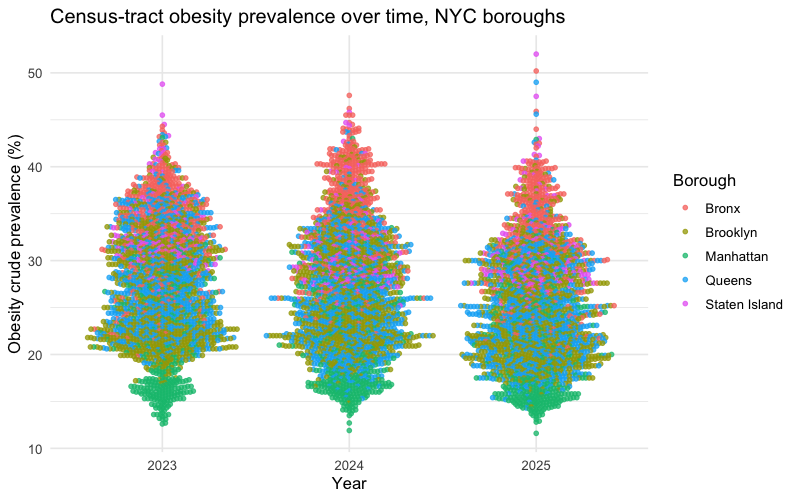

In [26]:
%%R -w 800 -h 500 -r 100
ggplot(plot_df, aes(x = Year, y = OBESITY_CrudePrev, color = Borough)) +
  geom_beeswarm(cex = 0.6, size = 1.2, alpha = 0.75) +
  labs(
    title = "Census-tract obesity prevalence over time, NYC boroughs",
    x     = "Year",
    y     = "Obesity crude prevalence (%)",
    color = "Borough"
  ) +
  theme_minimal(base_size = 12)

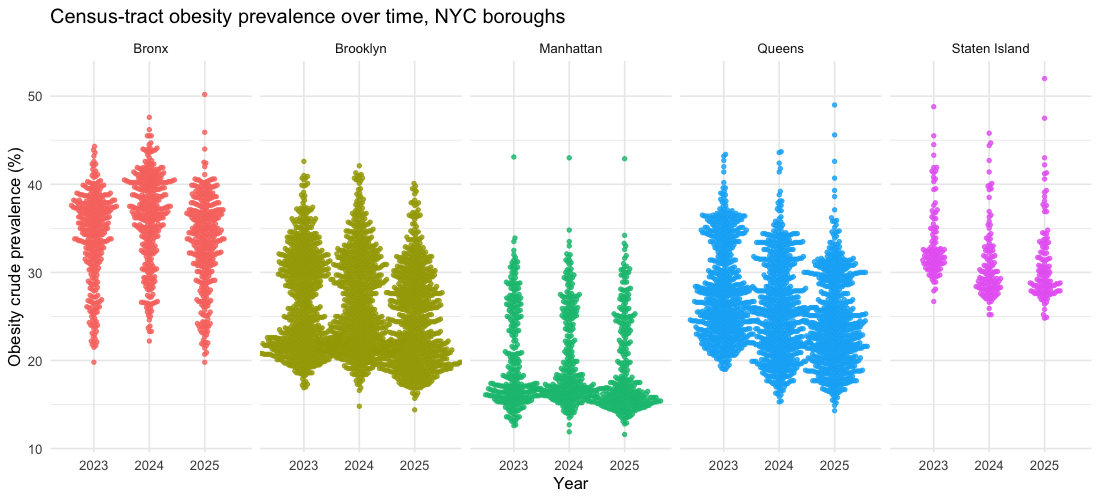

In [27]:
%%R -w 1100 -h 500 -r 100
# Optional: one panel per borough so swarms don't overlap
ggplot(plot_df, aes(x = Year, y = OBESITY_CrudePrev, color = Borough)) +
  geom_beeswarm(cex = 1.2, size = 1.1, alpha = 0.8) +
  facet_wrap(~ Borough, nrow = 1) +
  labs(
    title = "Census-tract obesity prevalence over time, NYC boroughs",
    x     = "Year",
    y     = "Obesity crude prevalence (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

## Flipped axes: obesity on x, year on y

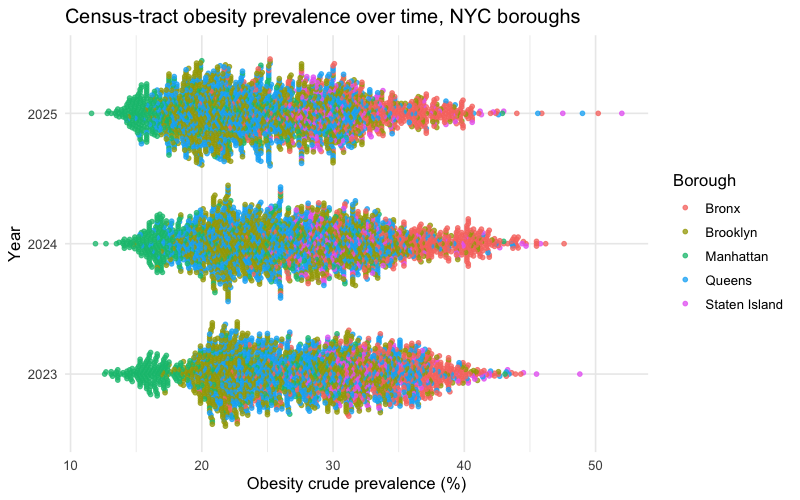

In [28]:
%%R -w 800 -h 500 -r 100
# Flipped axes: obesity on x, year on y
ggplot(plot_df, aes(x = OBESITY_CrudePrev, y = Year, color = Borough)) +
  geom_beeswarm(cex = 0.6, size = 1.2, alpha = 0.75, groupOnX = FALSE) +
  labs(
    title = "Census-tract obesity prevalence over time, NYC boroughs",
    x     = "Obesity crude prevalence (%)",
    y     = "Year",
    color = "Borough"
  ) +
  theme_minimal(base_size = 12)

## Highlight: Tract 664.01 vs. Tract 532 — both in Queens, similar obesity, very different residuals

- **Queens Tract 664.01** (FIPS `36081066401`) — actual 32.8%, predicted 15.36% → residual **+17.44** (high income / low poverty, but high obesity).
- **Queens Tract 532** (FIPS `36081053200`) — actual 32.1%, predicted 32.05% → residual **+0.05** (regression nailed it).

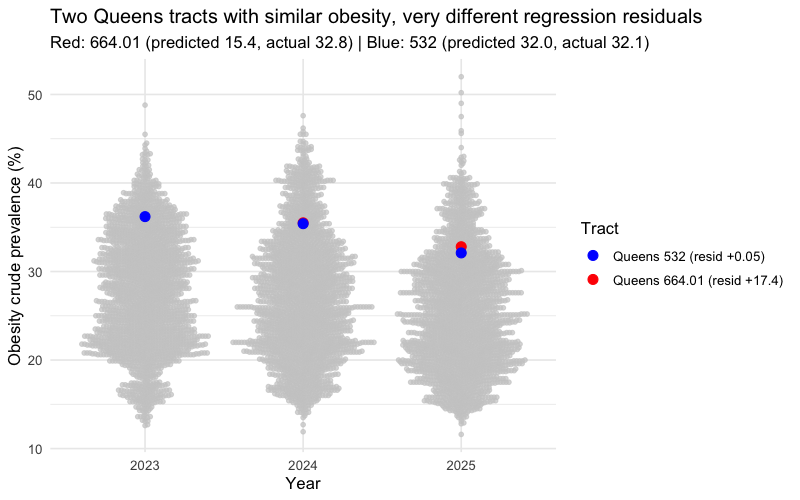

In [29]:
%%R -w 800 -h 500 -r 100
target_fips <- c(
  "Queens 664.01 (resid +17.4)" = "36081066401",
  "Queens 532 (resid +0.05)"    = "36081053200"
)

highlight_df <- plot_df %>%
  mutate(target = ifelse(TractFIPS %in% target_fips,
                         names(target_fips)[match(TractFIPS, target_fips)],
                         NA_character_))

ggplot(highlight_df, aes(x = Year, y = OBESITY_CrudePrev)) +
  geom_beeswarm(data = filter(highlight_df, is.na(target)),
                color = "grey80", cex = 0.6, size = 1.2, alpha = 0.7) +
  geom_point(data = filter(highlight_df, !is.na(target)),
             aes(color = target), size = 3) +
  scale_color_manual(values = c(
    "Queens 664.01 (resid +17.4)" = "red",
    "Queens 532 (resid +0.05)"    = "blue"
  )) +
  labs(
    title    = "Two Queens tracts with similar obesity, very different regression residuals",
    subtitle = "Red: 664.01 (predicted 15.4, actual 32.8) | Blue: 532 (predicted 32.0, actual 32.1)",
    x        = "Year",
    y        = "Obesity crude prevalence (%)",
    color    = "Tract"
  ) +
  theme_minimal(base_size = 12)

## Mean obesity rate by borough over time

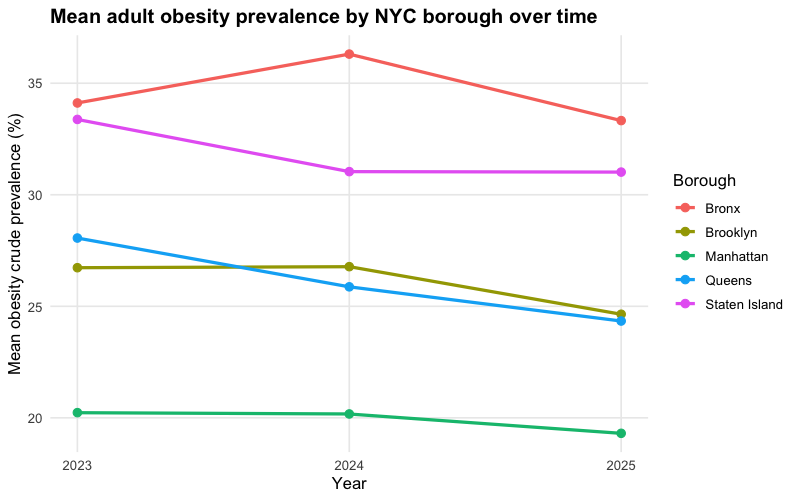

In [30]:
%%R -w 800 -h 500 -r 100
borough_means <- plot_df %>%
  group_by(Borough, Year) %>%
  summarise(mean_obesity = mean(OBESITY_CrudePrev, na.rm = TRUE), .groups = "drop") %>%
  mutate(Year = as.integer(as.character(Year)))

ggplot(borough_means, aes(x = Year, y = mean_obesity, color = Borough, group = Borough)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2.5) +
  scale_x_continuous(breaks = unique(borough_means$Year)) +
  labs(
    title = "Mean adult obesity prevalence by NYC borough over time",
    x     = "Year",
    y     = "Mean obesity crude prevalence (%)",
    color = "Borough"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

## Borough mean obesity, 2025 (horizontal bar)

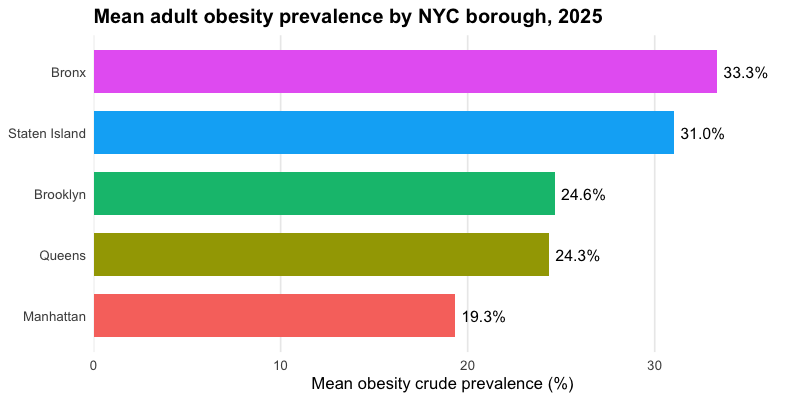

In [31]:
%%R -w 800 -h 400 -r 100
borough_2025 <- plot_df %>%
  filter(as.integer(as.character(Year)) == 2025) %>%
  group_by(Borough) %>%
  summarise(mean_obesity = mean(OBESITY_CrudePrev, na.rm = TRUE), .groups = "drop") %>%
  mutate(Borough = reorder(Borough, mean_obesity))

ggplot(borough_2025, aes(x = mean_obesity, y = Borough, fill = Borough)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", mean_obesity)),
            hjust = -0.15, size = 4) +
  scale_x_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(
    title = "Mean adult obesity prevalence by NYC borough, 2025",
    x     = "Mean obesity crude prevalence (%)",
    y     = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    legend.position = "none",
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank()
  )